In [6]:
import pandas as pd 
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

df = pd.read_csv("data/clean_drug_overdose_death.csv")
df.head()

,GEOID,NAME,ACS Total Population (2009-2013),Percent of Population Under 15 (2009-2013),Percent of Population Aged 15 to 64 (2009-2013),Percent of Population 65+ (2009-2013),Percent of Population White (non-Hispanic) (2009-2013),Percent of Populaiton Black (non-Hispanic) (2009-2013),Percent of Population Hispanic or Latino (2009-2013),Percent of Population Asian (non-Hispanic) (2009-2013),...,Number of Mental Health Facilities (As of March 2023),MDsPerCapita,Urbanicity,Social Resilience Score,Economic Risk Score,Social Risk Score,Economic Resilience Score,Prosperity Index Score,county,state
0,1,Alabama,4799277,0.1934,0.6647,0.1418,0.6679,0.2616,0.0392,0.0118,...,103.0,8.24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Alabama
1,1001,"Autauga County, Alabama",54907,0.2148,0.6588,0.1265,0.7648,0.1822,0.0249,0.0096,...,0.0,3.63,Urban,4.0,2.0,2.0,5.0,3.0,Autauga County,Alabama
2,1003,"Baldwin County, Alabama",187114,0.1882,0.6389,0.1729,0.8339,0.0943,0.0445,0.0071,...,1.0,7.52,Urban,3.0,1.0,2.0,2.0,2.0,Baldwin County,Alabama
3,1005,"Barbour County, Alabama",27321,0.1793,0.6705,0.1502,0.4631,0.4631,0.0490,0.0019,...,1.0,0.00,Rural,5.0,5.0,3.0,4.0,5.0,Barbour County,Alabama
4,1007,"Bibb County, Alabama",22754,0.1811,0.6831,0.1358,0.7486,0.2166,0.0195,0.0011,...,0.0,8.86,Urban,4.0,4.0,4.0,3.0,4.0,Bibb County,Alabama


In [7]:
df.columns

Index(['GEOID', 'NAME', 'ACS Total Population (2009-2013)',
       'Percent of Population Under 15 (2009-2013)',
       'Percent of Population Aged 15 to 64 (2009-2013)',
       'Percent of Population 65+ (2009-2013)',
       'Percent of Population White (non-Hispanic) (2009-2013)',
       'Percent of Populaiton Black (non-Hispanic) (2009-2013)',
       'Percent of Population Hispanic or Latino (2009-2013)',
       'Percent of Population Asian (non-Hispanic) (2009-2013)',
       'Percent of Population Native American/Alaska Native (non-Hispanic) (2009-2013)',
       'Percent of Population Native Hawaiian/Pacific Islander (2009-2013)',
       'Percent of Population Aged 25+ who Have at Least a High School Diploma (2009-2013)',
       'Percent of Population Aged 25+ who Have a Bachelor's Degree or More (2009-2013)',
       'Poverty Rate (2009-2013)', 'Median Household Income (2009-2013)',
       'Unemployment Rate (2009-2013)',
       'Percent of Residents with a Disability (Aged 18-64) 

In [8]:
df = df[['county', 'state', 'Crude Death Rate (2010-2013)', 'Death Count (2010-2013)', 
         'Crude Opioid Death Rate (2010-2013)', 'Opioid Death Count (2010-2013)', 
         'Crude Opioid Death Rate (2014-2017)', 'Opioid Death Count (2014-2017)',
         'Crude Opioid Death Rate (2018-2021)', 'Opioid Death Count (2018-2021)',
         'Number of Mental Health Facilities (As of March 2023)']]
ga_state = df[df['state'] == "Georgia"] 
# Remove rows where county is missing
ga_state_clean = ga_state[ga_state['county'].notna()]

# Optional: reset index
ga_state_clean = ga_state_clean.reset_index(drop=True)
ga_state_clean[:20]


,county,state,Crude Death Rate (2010-2013),Death Count (2010-2013),Crude Opioid Death Rate (2010-2013),Opioid Death Count (2010-2013),Crude Opioid Death Rate (2014-2017),Opioid Death Count (2014-2017),Crude Opioid Death Rate (2018-2021),Opioid Death Count (2018-2021),Number of Mental Health Facilities (As of March 2023)
0,Appling County,Georgia,Suppressed,Suppressed,Suppressed,Suppressed,Suppressed,Suppressed,Suppressed,Suppressed,2.0
1,Atkinson County,Georgia,Suppressed,Suppressed,Suppressed,Suppressed,Suppressed,Suppressed,Suppressed,Suppressed,0.0
2,Bacon County,Georgia,Suppressed,Suppressed,Suppressed,Suppressed,Suppressed,Suppressed,Suppressed,Suppressed,1.0
3,Baker County,Georgia,Suppressed,Suppressed,Suppressed,Suppressed,Suppressed,Suppressed,Suppressed,Suppressed,0.0
4,Baldwin County,Georgia,Suppressed,Suppressed,Suppressed,Suppressed,Suppressed,Suppressed,Suppressed,Suppressed,0.0
5,Banks County,Georgia,20.6*,10,Suppressed,Suppressed,NaN,11,26.5*,13,0.0
6,Barrow County,Georgia,20.9,39,11.8,22,13,26,21.2,47,0.0
7,Bartow County,Georgia,25.6,69,14.5,39,19.3,53,29.6,85,1.0
8,Ben Hill County,Georgia,Suppressed,Suppressed,Suppressed,Suppressed,Suppressed,Suppressed,Suppressed,Suppressed,0.0
9,Berrien County,Georgia,Suppressed,Suppressed,Suppressed,Suppressed,Suppressed,Suppressed,31.2*,15,0.0


In [9]:
ga_state_clean.to_csv("ga_state_clean.csv", index=False)

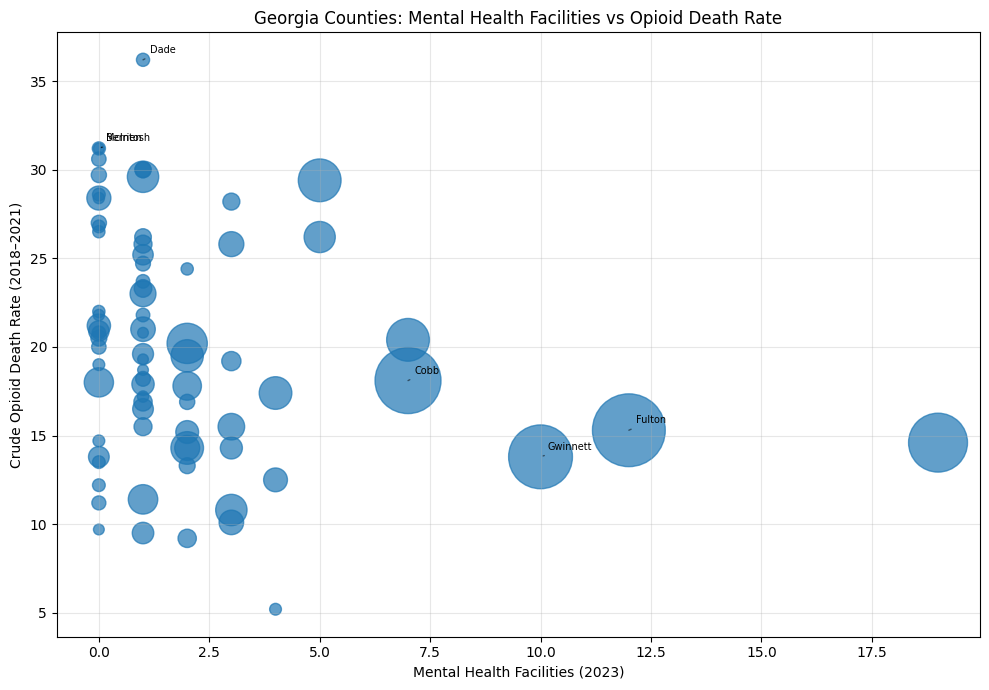

In [10]:
# Keep only county rows
# df = ga_state_clean.copy()
df = pd.read_csv("ga_state_clean.csv")

# Columns to use
facility_col = "Number of Mental Health Facilities (As of March 2023)"
rate_col = "Crude Opioid Death Rate (2018-2021)"
count_col = "Opioid Death Count (2018-2021)"

cols = [rate_col, count_col]

# Clean data
for col in cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.replace("*", "", regex=False)
        .replace("Suppressed", pd.NA)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove missing rows
plot_df = df.dropna(subset=cols)

# Plot
plt.figure(figsize=(10, 7))

plt.scatter(
    plot_df[facility_col],
    plot_df[rate_col],
    s=plot_df[count_col] * 6,
    alpha=0.7
)

plt.xlabel("Mental Health Facilities (2023)")
plt.ylabel("Crude Opioid Death Rate (2018–2021)")
plt.title("Georgia Counties: Mental Health Facilities vs Opioid Death Rate")

plt.grid(True, alpha=0.3)

# Label top counties
# top = plot_df.nlargest(15, rate_col)

# for _, row in top.iterrows():
#     label = str(row["county"]).replace(" County", "")
#     print(label)
#     plt.annotate(
#         label,
#         (row[facility_col], row[rate_col]),
#         fontsize=8
#     )

top_rate = plot_df.nlargest(3, rate_col)
top_count = plot_df.nlargest(3, count_col)

to_label = pd.concat([top_rate, top_count]).drop_duplicates()

for _, row in to_label.iterrows():
    if pd.notna(row["county"]):
        label = str(row["county"]).replace(" County", "")
        
        plt.annotate(
            label,
            (row[facility_col], row[rate_col]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=7,
            arrowprops=dict(arrowstyle="-", alpha=0.5)
        )

plt.tight_layout()
plt.show()

In [11]:
# Dade County
# Cobb County
tt = df[df['county'].isin(['Dade County', 'Cobb County'])]
tt[['Crude Opioid Death Rate (2018-2021)','Opioid Death Count (2018-2021)',	'Number of Mental Health Facilities (As of March 2023)']]

# Big circles (like Case A) → high burden (many deaths)
# High points (like Case B) → high risk (high rate)

,Crude Opioid Death Rate (2018-2021),Opioid Death Count (2018-2021),Number of Mental Health Facilities (As of March 2023)
32,18.1,376.0,7.0
40,36.2,15.0,1.0


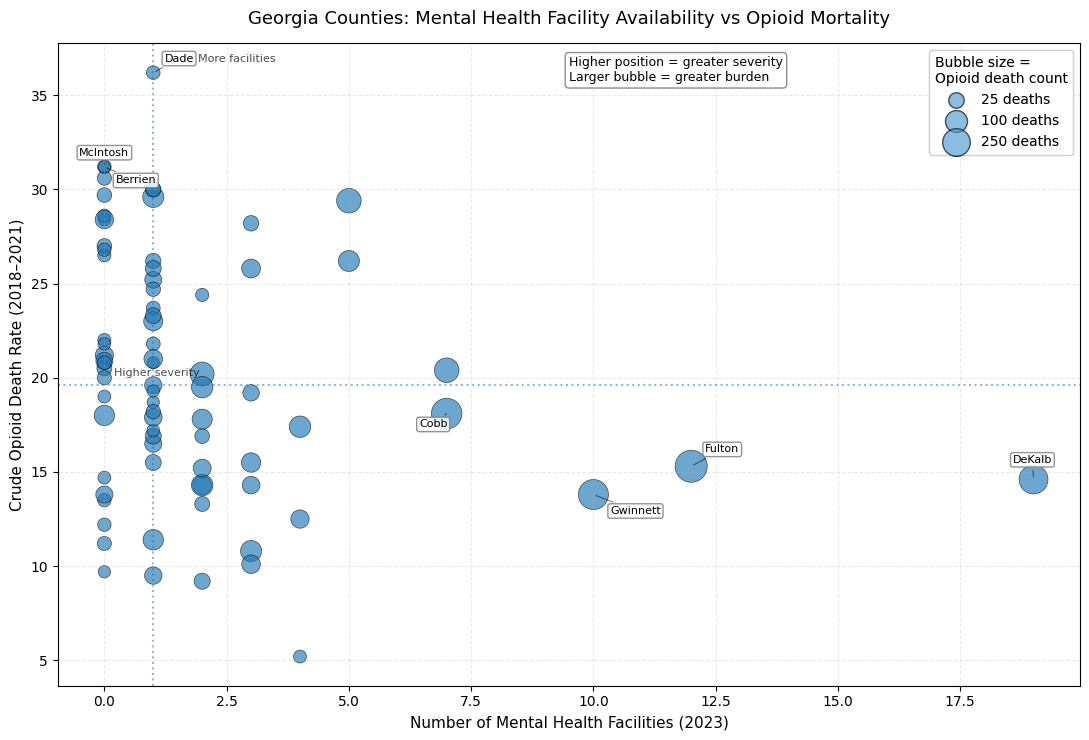

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

# -----------------------------
# Copy data
# -----------------------------
# df = ga_state_clean.copy()

df = pd.read_csv("ga_state_clean.csv")

# Columns
facility_col = "Number of Mental Health Facilities (As of March 2023)"
rate_col = "Crude Opioid Death Rate (2018-2021)"
count_col = "Opioid Death Count (2018-2021)"

# Clean only needed columns
cols = [facility_col, rate_col, count_col]

for col in cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.replace("*", "", regex=False)
        .replace("Suppressed", pd.NA)
        .replace("nan", pd.NA)
        .replace("NaN", pd.NA)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Keep rows usable for plotting
plot_df = df.dropna(subset=cols + ["county"]).copy()

# Short county names
plot_df["county_label"] = plot_df["county"].astype(str).str.replace(" County", "", regex=False)

# -----------------------------
# Bubble size scaling
# -----------------------------
# Use sqrt scaling so very large counties do not dominate too much
plot_df["bubble_size"] = (plot_df[count_col] ** 0.5) * 25

# -----------------------------
# Pick counties to label
# -----------------------------
top_rate = plot_df.nlargest(3, rate_col)
top_count = plot_df.nlargest(3, count_col)
top_facility = plot_df.nlargest(2, facility_col)

to_label = pd.concat([top_rate, top_count, top_facility]).drop_duplicates()

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(11, 7.5))

scatter = ax.scatter(
    plot_df[facility_col],
    plot_df[rate_col],
    s=plot_df["bubble_size"],
    alpha=0.65,
    edgecolors="black",
    linewidth=0.5
)

# Axis labels and title
ax.set_xlabel("Number of Mental Health Facilities (2023)", fontsize=11)
ax.set_ylabel("Crude Opioid Death Rate (2018–2021)", fontsize=11)
ax.set_title(
    "Georgia Counties: Mental Health Facility Availability vs Opioid Mortality",
    fontsize=13,
    pad=14
)

ax.grid(True, alpha=0.25, linestyle="--")

# -----------------------------
# Annotate important counties
# -----------------------------
# Hand-tuned offsets reduce overlap
offsets = [
    (8, 8), (8, -12), (-18, 8), (10, 10), (-20, -10), (12, -14), (-15, 12), (10, 0)
]

for i, (_, row) in enumerate(to_label.iterrows()):
    dx, dy = offsets[i % len(offsets)]
    ax.annotate(
        row["county_label"],
        (row[facility_col], row[rate_col]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.85),
        arrowprops=dict(arrowstyle="-", alpha=0.5, lw=0.8)
    )

# -----------------------------
# Bubble size legend
# -----------------------------
# Use example death counts for legend
legend_counts = [25, 100, 250]
legend_sizes = [(x ** 0.5) * 25 for x in legend_counts]

# handles = [
#     plt.scatter([], [], s=size, edgecolors="black", linewidth=0.5, alpha=0.65)
#     for size in legend_sizes
# ]
handles = [
    plt.scatter([], [], s=size, color="#4F9AD1", alpha=0.6, edgecolors="black")
    for size in legend_sizes
]

legend1 = ax.legend(
    handles,
    [f"{c} deaths" for c in legend_counts],
    title="Bubble size =\nOpioid death count",
    loc="upper right",
    frameon=True
)
ax.add_artist(legend1)

# -----------------------------
# Explain severity vs burden
# -----------------------------
ax.text(
    0.50, 0.98,
    "Higher position = greater severity\nLarger bubble = greater burden",
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9)
)

# -----------------------------
# Optional quadrant-style guidance
# -----------------------------
median_fac = plot_df[facility_col].median()
median_rate = plot_df[rate_col].median()

ax.axvline(median_fac, linestyle=":", alpha=0.5)
ax.axhline(median_rate, linestyle=":", alpha=0.5)

ax.text(
    median_fac + 0.92, ax.get_ylim()[1] - 1,
    "More facilities",
    fontsize=8, alpha=0.7
)
ax.text(
    0.2, median_rate + 0.5,
    "Higher severity",
    fontsize=8, alpha=0.7
)

plt.tight_layout()
plt.show()

In [13]:
df = df[["state", "county", 
        "Poverty Rate (2009-2013)", "Poverty Rate (2013-2017)", "Poverty Rate (2017-2021)",
        "Median Household Income (2009-2013)", "Median Household Income (2013-2017)", "Median Household Income (2017-2021)",
        "Unemployment Rate (2009-2013)", "Unemployment Rate (2013-2017)", "Unemployment Rate (2017-2021)",
        "Opioid Death Count (2010-2013)", "Opioid Death Count (2014-2017)", "Opioid Death Count (2018-2021)",
        "Crude Opioid Death Rate (2010-2013)", "Crude Opioid Death Rate (2014-2017)", "Crude Opioid Death Rate (2018-2021)", 
        "Percent of Popualtion Employed in Mining and Natural Resources (2009-2013)", 
        "Percent of Popualtion Employed in Mining and Natural Resources (2013-2017)",
        "Percent of Popualtion Employed in Mining and Natural Resources (2017-2021)",
        "Percent of Popualtion Employed in Construction (2009-2013)",
        "Percent of Popualtion Employed in Construction (2013-2017)",
        "Percent of Popualtion Employed in Construction (2017-2021)",         
        "Percent of Popualtion Employed in Manufacturing (2009-2013)",
        "Percent of Popualtion Employed in Manufacturing (2013-2017)",
        "Percent of Popualtion Employed in Manufacturing (2017-2021)",
        "Percent of Popualtion Employed in Trade Transportation and Utilities (2009-2013)",
        "Percent of Popualtion Employed in Trade Transportation and Utilities (2013-2017)",
        "Percent of Popualtion Employed in Trade Transporation and Utilities (2017-2021)",
        "Percent of Population Aged 25+ who Have at Least a High School Diploma (2009-2013)",
        "Percent of Population Aged 25+ who Have a Bachelor's Degree or More (2009-2013)",
        "Percent of Population Aged 25+ who Have at Least a High School Diploma (2013-2017)",
        "Percent of Population Aged 25+ who Have a Bachelor's Degree or More (2013-2017)",
        "Percent of Population Aged 25+ who Have at Least a High School Diploma (2017-2021)",
        "Percent of Population Aged 25+ who Have a Bachelor's Degree or More (2017-2021)",
         "Economic Resilience Score"]]

df = df.dropna()
# df = df[df["Crude Opioid Death Rate (2018-2021)"] != "Suppressed"]

df

KeyError: '[\'Poverty Rate (2009-2013)\', \'Poverty Rate (2013-2017)\', \'Poverty Rate (2017-2021)\', \'Median Household Income (2009-2013)\', \'Median Household Income (2013-2017)\', \'Median Household Income (2017-2021)\', \'Unemployment Rate (2009-2013)\', \'Unemployment Rate (2013-2017)\', \'Unemployment Rate (2017-2021)\', \'Percent of Popualtion Employed in Mining and Natural Resources (2009-2013)\', \'Percent of Popualtion Employed in Mining and Natural Resources (2013-2017)\', \'Percent of Popualtion Employed in Mining and Natural Resources (2017-2021)\', \'Percent of Popualtion Employed in Construction (2009-2013)\', \'Percent of Popualtion Employed in Construction (2013-2017)\', \'Percent of Popualtion Employed in Construction (2017-2021)\', \'Percent of Popualtion Employed in Manufacturing (2009-2013)\', \'Percent of Popualtion Employed in Manufacturing (2013-2017)\', \'Percent of Popualtion Employed in Manufacturing (2017-2021)\', \'Percent of Popualtion Employed in Trade T

In [ ]:
ga_state = df[df['state'] == "Georgia"] 
ga_state

In [47]:
col = "Crude Opioid Death Rate (2018-2021)"

df[col] = (
    df[col]
    .astype(str)
    .str.replace("*", "", regex=False)
)

df[col] = pd.to_numeric(df[col], errors="coerce")

set(df["Crude Opioid Death Rate (2018-2021)"].values)




{np.float64(2.0),
 np.float64(4.4),
 np.float64(4.6),
 np.float64(4.7),
 np.float64(4.9),
 np.float64(5.1),
 np.float64(5.2),
 np.float64(5.3),
 np.float64(5.4),
 np.float64(5.5),
 np.float64(5.6),
 np.float64(5.8),
 np.float64(5.9),
 np.float64(6.0),
 np.float64(6.1),
 np.float64(6.2),
 np.float64(6.3),
 np.float64(6.6),
 np.float64(6.7),
 np.float64(6.8),
 np.float64(6.9),
 np.float64(7.0),
 np.float64(7.1),
 np.float64(7.4),
 np.float64(7.5),
 np.float64(7.6),
 np.float64(7.7),
 np.float64(7.9),
 np.float64(8.0),
 np.float64(8.1),
 np.float64(8.2),
 np.float64(8.3),
 np.float64(8.4),
 np.float64(8.5),
 np.float64(8.6),
 np.float64(8.8),
 np.float64(8.9),
 np.float64(9.0),
 np.float64(9.1),
 np.float64(9.2),
 np.float64(9.3),
 np.float64(9.4),
 np.float64(9.5),
 np.float64(9.6),
 np.float64(9.7),
 np.float64(10.0),
 np.float64(10.1),
 np.float64(10.2),
 np.float64(10.3),
 np.float64(10.4),
 np.float64(10.5),
 np.float64(10.6),
 np.float64(10.7),
 np.float64(10.8),
 np.float64(10.9),


In [48]:
# poverty = df[["Poverty Rate (2009-2013)",
#         "Poverty Rate (2013-2017)",
#         "Poverty Rate (2017-2021)", "county"]]

# poverty = poverty.dropna()
# poverty.isna().sum()

/var/folders/hf/5l6z3q9j19bb8js1745h40vc0000gn/T/ipykernel_19886/3465934344.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=poverty_long, x="period", y="poverty", estimator="mean", ci=None)


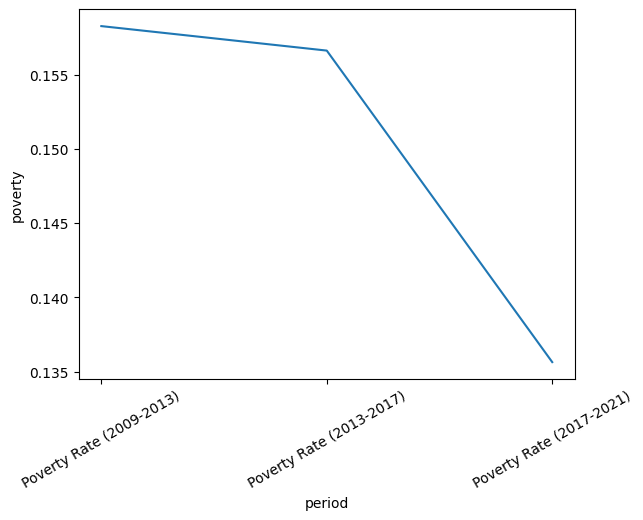

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

poverty_long = df.melt(
    id_vars=["state","county"],
    value_vars=[
        "Poverty Rate (2009-2013)",
        "Poverty Rate (2013-2017)",
        "Poverty Rate (2017-2021)"
    ],
    var_name="period",
    value_name="poverty"
)

sns.lineplot(data=poverty_long, x="period", y="poverty", estimator="mean", ci=None)
plt.xticks(rotation=30)
plt.show()


/var/folders/hf/5l6z3q9j19bb8js1745h40vc0000gn/T/ipykernel_19886/2526253405.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


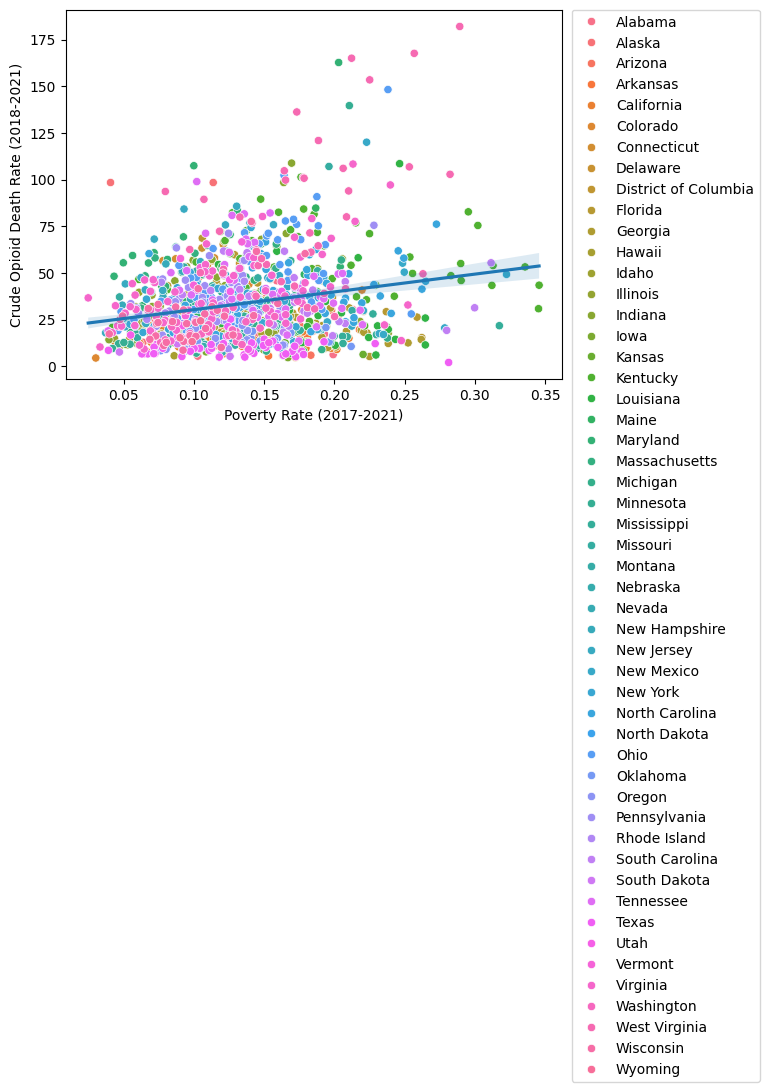

In [53]:
sns.scatterplot(
    data=df,
    x="Poverty Rate (2017-2021)",
    y="Crude Opioid Death Rate (2018-2021)",
    hue="state"
)
sns.regplot(
    data=df,
    x="Poverty Rate (2017-2021)",
    y="Crude Opioid Death Rate (2018-2021)",
    scatter=False
)


plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

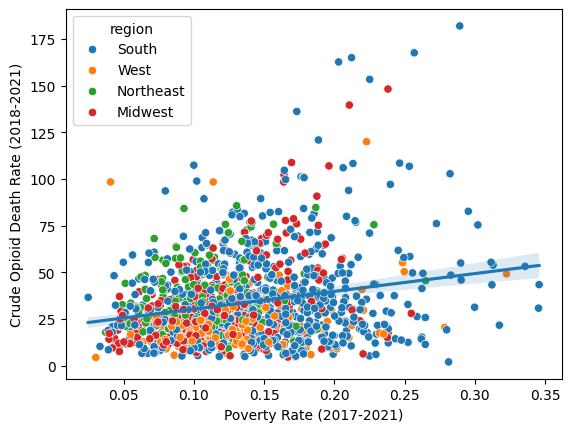

In [55]:
county_list = df["county"].unique().tolist()

region_map = {
    "Alabama":"South","Alaska":"West","Arizona":"West","Arkansas":"South",
    "California":"West","Colorado":"West","Connecticut":"Northeast","Delaware":"South",
    "District of Columbia":"South","Florida":"South","Georgia":"South","Hawaii":"West",
    "Idaho":"West","Illinois":"Midwest","Indiana":"Midwest","Iowa":"Midwest",
    "Kansas":"Midwest","Kentucky":"South","Louisiana":"South","Maine":"Northeast",
    "Maryland":"South","Massachusetts":"Northeast","Michigan":"Midwest","Minnesota":"Midwest",
    "Mississippi":"South","Missouri":"Midwest","Montana":"West","Nebraska":"Midwest",
    "Nevada":"West","New Hampshire":"Northeast","New Jersey":"Northeast","New Mexico":"West",
    "New York":"Northeast","North Carolina":"South","North Dakota":"Midwest","Ohio":"Midwest",
    "Oklahoma":"South","Oregon":"West","Pennsylvania":"Northeast","Rhode Island":"Northeast",
    "South Carolina":"South","South Dakota":"Midwest","Tennessee":"South","Texas":"South",
    "Utah":"West","Vermont":"Northeast","Virginia":"South","Washington":"West",
    "West Virginia":"South","Wisconsin":"Midwest","Wyoming":"West"
}
df["region"] = df["state"].map(region_map)

sns.scatterplot(
    data=df,
    x="Poverty Rate (2017-2021)",
    y="Crude Opioid Death Rate (2018-2021)",
    hue="region"
)

sns.regplot(
    data=df,
    x="Poverty Rate (2017-2021)",
    y="Crude Opioid Death Rate (2018-2021)",
    scatter=False
)

plt.show()

 

In [ ]:
Economic visualisations:
Overdose deaths/time
line graph
bar chart
Unemployment rate, median income, and job types correlation with overdose rate
dot plot
Bar chart
heat map with overlaid numbers
Mental health/substance use facility correlation with overdose rate
dot plot
heat map with overlaid numbers
Education levels and overdose rate
dot plot
Heat map with overlaid numbers
